In [10]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns

# import own modules
_repo_name = "ofdma-spectrum-anomalies-simulation"
_module_path = os.getcwd()[: os.getcwd().find(_repo_name) + len(_repo_name)]
sys.path.append(os.path.join(os.path.abspath(_module_path), "src"))

from utils.data_utils import get_datapath

# some parameters and configuration for figures
COL_WIDTH = 3.5 # in inches
TWO_COL_WIDTH = 7.16 # in inches
RATIO = 1.618 # golden ratio
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 8

figure_path = os.path.join("..", "figures")

In [11]:
DATASET_NR = 10

datapath = get_datapath(_repo_name)
datapath = os.path.join(datapath, str(DATASET_NR))

min_max = pd.read_csv(os.path.join(datapath, "spectrogram_min_max.csv"))
min_val = min_max["min_val"].values[0]
max_val = min_max["max_val"].values[0]

labels = pd.read_csv(os.path.join(datapath, "labels.csv"))
labels

,jammer_type,jammer_power,jammer_location,num_legitimate_transmitters,snr_by_su_0,snr_by_su_1,snr_by_su_2,snr_by_su_3,snr_by_su_4,snr_by_su_5,...,sjr_by_su_11,sjr_by_su_12,sjr_by_su_13,sjr_by_su_14,sjr_by_su_15,sjr_by_su_16,sjr_by_su_17,sjr_by_su_18,sjr_by_su_19,sjr_by_su_20
0,no jammer,NaN,NaN,6,31.209632,29.087556,23.949343,25.491729,27.289219,15.396972,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
1,no jammer,NaN,NaN,7,34.032179,30.982281,35.140019,26.697514,21.948590,34.712492,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
2,no jammer,NaN,NaN,8,22.092530,27.909499,27.710939,25.989771,25.974686,31.538746,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
3,no jammer,NaN,NaN,5,5.554370,20.997804,30.675459,29.406464,24.727502,10.794082,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
4,no jammer,NaN,NaN,10,10.073458,55.067556,37.929117,22.422916,22.216434,39.618932,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
5,no jammer,NaN,NaN,3,9.283629,5.221927,8.763357,23.303142,5.359106,23.837314,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
6,no jammer,NaN,NaN,4,5.432545,26.580838,19.018719,24.020663,33.157998,8.043868,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
7,no jammer,NaN,NaN,10,29.056135,25.695063,23.867073,23.710404,25.875967,32.915512,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
8,no jammer,NaN,NaN,10,19.708942,27.390807,27.242198,33.667378,27.140908,28.307541,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
9,no jammer,NaN,NaN,6,17.578364,13.501735,12.046802,27.492131,24.579440,39.517842,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf


In [12]:
labels["jammer_type"].value_counts()

jammer_type
no jammer     10
deceptive      2
sweep          2
barrage        2
pilot          2
random_hop     2
Name: count, dtype: int64

In [13]:
labels["jammer_power"].value_counts()

jammer_power
20.0    3
30.0    2
15.0    2
0.0     1
25.0    1
10.0    1
Name: count, dtype: int64

Mean SNR: 25.06 dB, Std SNR: 7.21 dB
Mean SJR: 10.96 dB, Std SJR: 18.33 dB


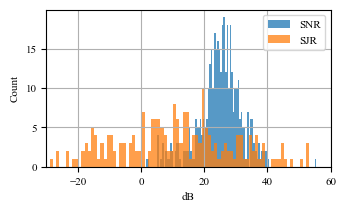

In [14]:
# analyze snr and sjr
def aggregate_over_sus(df, measure):
    all_vals = []
    for col in df.columns:
        if col.startswith(measure):
            vals = df[col].values
            vals = vals[np.isfinite(vals)]  # Filter out inf values of unjammed samples for SJR
            all_vals.extend(vals)

    return np.array(all_vals)

snr_values = aggregate_over_sus(labels, "snr")
print(f"Mean SNR: {np.mean(snr_values):.2f} dB, Std SNR: {np.std(snr_values):.2f} dB")
sjr_values = aggregate_over_sus(labels, "sjr")
print(f"Mean SJR: {np.mean(sjr_values):.2f} dB, Std SJR: {np.std(sjr_values):.2f} dB")

fig, ax = plt.subplots(figsize=(COL_WIDTH, COL_WIDTH/RATIO))
sns.histplot(snr_values, label="SNR", linewidth=0, binwidth=0.5)
sns.histplot(sjr_values, label="SJR", linewidth=0, binwidth=1.0)
plt.xlabel("dB")
# plt.title("Distribution of SNR and SJR")
plt.xlim(-30, 60)
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(os.path.join(figure_path, "snr_sjr_distribution.pdf"))

In [15]:
def get_filename(sample_idx, su_idx):
    return os.path.join(datapath, "images", f"spectrogram-{str(sample_idx).zfill(5)}-{str(su_idx).zfill(2)}.png")

example_anomaly_types = {
    "deceptive": (10000, 2),
    "sweep": (12006, 19),
    "barrage": (14000, 4),
    "pilot": (16002, 16),
    "random_hop": (18001, 16)
}

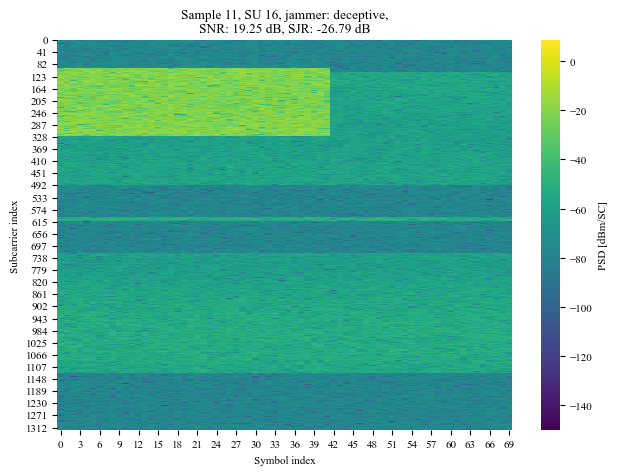

In [19]:
with_labels = True
save_fig = False
plot_type = "custom"  # either jammer types or "custom" sample and SU index shall be set manually
normalized_to_dataset = True

if plot_type in example_anomaly_types:
    sample_idx = example_anomaly_types[plot_type][0]
    su_idx = example_anomaly_types[plot_type][1]
else:
    sample_idx = 11
    su_idx = 16

if normalized_to_dataset:
    c_min_val = min_val
    c_max_val = max_val
else:
    c_min_val = None
    c_max_val = None

img = Image.open(get_filename(sample_idx, su_idx))
img = np.array(img)/255.0 * (max_val - min_val) + min_val

fig, ax = plt.subplots()

if with_labels:
    sns.heatmap(img, cmap="viridis", cbar_kws={"label": "PSD [dBm/SC]"}, vmin=c_min_val, vmax=c_max_val)
    plt.title(
        f"Sample {sample_idx}, SU {su_idx}, jammer: {labels[f'jammer_type'].values[sample_idx]},\n"
        f"SNR: {labels[f'snr_by_su_{su_idx}'].values[sample_idx]:.2f} dB, SJR: {labels[f'sjr_by_su_{su_idx}'].values[sample_idx]:.2f} dB"
    )
    plt.xlabel("Symbol index")
    plt.ylabel("Subcarrier index")
else:
    plt.imshow(img, aspect="auto", origin="lower", cmap="viridis", interpolation="none", vmin=c_min_val, vmax=c_max_val)
    plt.axis("off")
plt.tight_layout()

if save_fig:

    if plot_type in example_anomaly_types:
        filename = f"example_{plot_type}_sample_{sample_idx}_su_{su_idx}"
    else:
        filename = f"sample_{sample_idx}_su_{su_idx}"

    if with_labels:
        filename += "_labeled"

    filename += ".pdf"

    plt.savefig(os.path.join(figure_path, filename), dpi=300, bbox_inches="tight")

<Axes: >

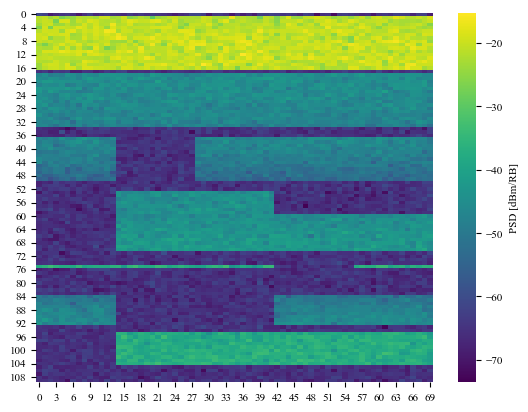

In [17]:
# reduce resolution by aggregating subcarriers
num_sc_per_rb = 12
def aggregate_subcarriers(spectrogram, num_sc_per_rb):
    num_rows, num_cols = spectrogram.shape
    num_aggregated_rows = num_rows // num_sc_per_rb
    aggregated_spectrogram = np.zeros((num_aggregated_rows, num_cols))

    for i in range(num_aggregated_rows):
        start_row = i * num_sc_per_rb
        end_row = start_row + num_sc_per_rb
        aggregated_spectrogram[i, :] = 10*np.log10(np.sum(10**(spectrogram[start_row:end_row, :] / 10), axis=0))

    return aggregated_spectrogram

sns.heatmap(aggregate_subcarriers(img, num_sc_per_rb), cmap="viridis", cbar_kws={"label": "PSD [dBm/RB]"})